In [1]:
import pandas as  pd 
import matplotlib.pyplot as plt 
import numpy as np
from SFstarred.save_and_read import read_hdf5_to_dict
from SFstarred.utils import correct_cutout_and_noise
from SFstarred.plots import plot_image_and_noisemap
import jax 
jax.config.update("jax_enable_x64", True) #we require double digit precision, this can be removed on GPU

/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [ ]:
from copy import deepcopy
from pprint import pprint
from starred.procedures.deconvolution_routines import multi_steps_deconvolution
from starred.plots.plot_function import view_deconv_model, plot_loss, plot_deconvolution
from SFstarred.stars_cut import normalize_data_error,normalize_data_error_photutils
from SFstarred.plots import plot_lens_and_noisemap

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
data_dict = pd.read_pickle("data_for_starred/data_for_starred.pickle")

In [8]:
zp_ab= data_dict["zp_ab"]

In [9]:
1/data_dict["pixel_scale"]

np.float64(25.239777889955267)

In [10]:
# zp_ab=hst_ab_zeropoint(path_data)

## Overview

This notebook applies the image-deconvolution procedure presented in the `start_here.ipynb` notebook from `starred`.

In [11]:

narrow_psfs = np.load('data_for_starred/narrow_psfs.npy')
#narrow_psfs = np.load('data_for_starred/narrow_psfs_hst.npy')

if len(narrow_psfs.shape)==2:
	narrow_psfs = narrow_psfs[None,:]

In [43]:
data = data_dict["data"].copy()
sigma2 = data_dict['sigma2'].copy()
noisemaps = np.sqrt(sigma2)#['sigma2']
exptime_seconds = data_dict["exptime_seconds"]
data, noise_map = normalize_data_error_photutils(data[0],noisemaps[0],exptime_seconds=exptime_seconds)
data, noise_map = data[None,:,:], noise_map[None,:,:]
image_positions = data_dict["coord_pix_images"]
image_names = data_dict["images_names"]
# coord_pix_images_dict = data_dict["coord_pix_images_dict"]

Photutils/SExtractor-like sky diagnostics
-----------------------------------------
detected center        = (25.0, 19.0) pix
bkg method             = sextractor
first bkg mode         = Background2D
final bkg mode         = Background2D
noise mode             = photutils_rms
box size               = 16
filter size            = 3
exclude percentile     = 50
median sky level       = 0.002316
median bkg RMS         = 0.008206
empirical sky median   = 0.0007485
empirical sky std      = 0.009568
median noise sky       = 0.008206
z mean / median / std  = 0.208, 0.092, 1.151
valid pixels           = 4489
source-mask pixels     = 2588
sky pixels             = 1901
OK: noise normalization looks reasonable.


In [44]:
data.shape

(1, 67, 67)

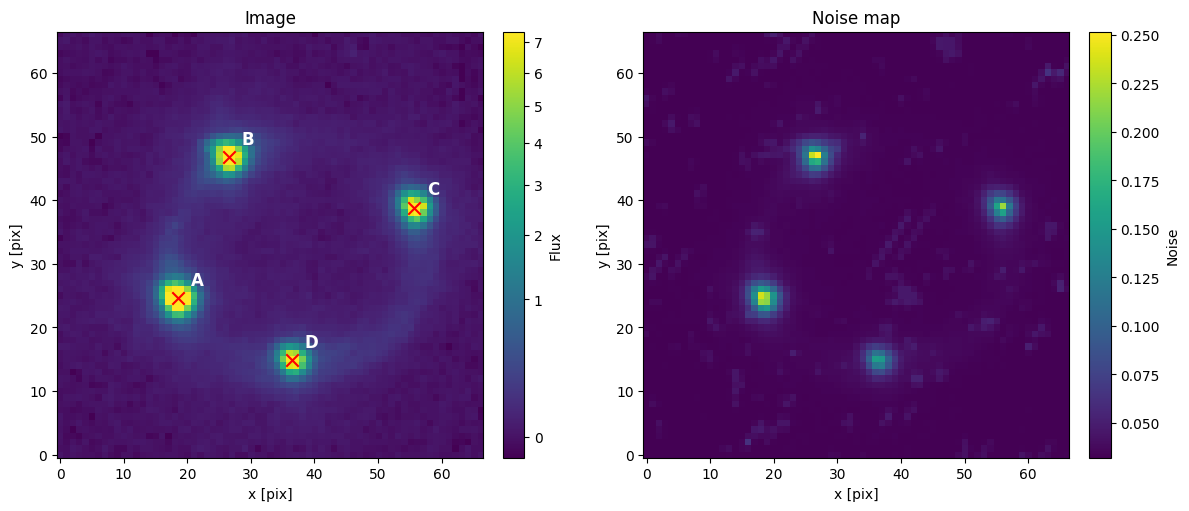

[ 22.67232417   3.50348717  -6.49744524 -14.49120888]
[  5.8444931  -18.08511658  13.77069129  -8.36317281]


In [45]:
fig, ax = plot_lens_and_noisemap(
    data=data[0],
    noisemaps=np.sqrt(sigma2[0]),
    image_positions=image_positions,
    image_names=image_names,
    #vmin=np.nanpercentile(data, 1),
    #vmax=np.nanpercentile(data, 99),
    #noise_vmin=np.nanpercentile(noisemaps, 1),
    #noise_vmax=np.nanpercentile(noisemaps, 99),
)
plt.show()
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset

ys = image_positions[:,1] - offset
try:
	coord_pix_non_images = data_dict["coord_pix_non_images"]
	ptx_non_lens = coord_pix_non_images[:,0] - offset
	pty_non_lens = coord_pix_non_images[:,1] - offset
except:
     print("no extra obj")
# xs = np.array([coord_pix_images_dict[name][0] for name in 'ABCD']) - offset
# ys = np.array([coord_pix_images_dict[name][1] for name in 'ABCD']) - offset

#
#np.median(data[0]),np.median(noisemaps[0])
print(xs)
print(ys)
scale = np.nanmax(data)
data /=scale
#noisemaps /=scale
sigma2 /=scale**2




/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/deconvolution/deconvolution.py:75: UserWarning: The narrow PSF does not have the same size as the upsampled image. This might be desired to speed up the computation but make sure it is at the resolution of the upsampled image.
  warnings.warn(


{'kwargs_analytic': {'c_x': array([ 22.67232417,   3.50348717,  -6.49744524, -14.49120888]), 'c_y': array([  5.8444931 , -18.08511658,  13.77069129,  -8.36317281]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([1., 1., 1., 1.])}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(17956,)), 'mean': array([0.])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}}


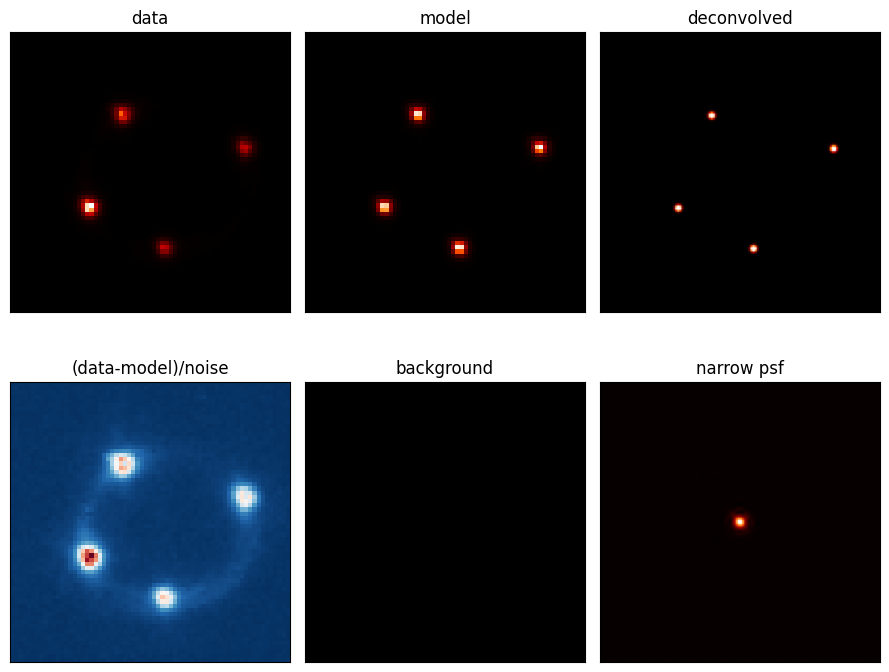

In [46]:
initial_c_x = xs
initial_c_y = ys


brightnesses = len(data) * 4 * [1]
subsampling_factor = 2
model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(
    data,
    sigma2,
    narrow_psfs,
    initial_c_x,
    initial_c_y,
    subsampling_factor=subsampling_factor,
    initial_a=brightnesses,
    N_sersic=0,
)

parameters = ParametersDeconv(
    kwargs_init,
    kwargs_fixed,
    kwargs_up=kwargs_up,
    kwargs_down=kwargs_down,
)

print(kwargs_init)
view_deconv_model(model, kwargs_init, data,sigma2)

Step 1, fixing : ['background']
Step 1/3 took  1 seconds
Kwargs partial at step 1/3 {'kwargs_analytic': {'a': Array([4.1704584 , 4.35926587, 5.43342311, 9.1690374 ], dtype=float64), 'c_x': Array([ 22.70510383,   3.4962551 ,  -6.45465747, -14.4463374 ], dtype=float64), 'c_y': Array([  5.72493756, -18.13680007,  13.72564399,  -8.44697196], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([-2.67235615e-04,  3.79712715e-05,  2.01946205e-03, ...,
        1.08440941e-03,  1.66164635e-03,  1.11898225e-03], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), d

optax.adabelief: 100%|██████████| 100/100 [00:00<00:00, 114.69it/s]


Step 2/3 took  1 seconds
Kwargs partial at step 2/3 {'kwargs_analytic': {'a': Array([4.11363855, 4.35718945, 5.33610805, 9.06903781], dtype=float64), 'c_x': Array([ 22.70510383,   3.4962551 ,  -6.45465747, -14.4463374 ], dtype=float64), 'c_y': Array([  5.72493756, -18.13680007,  13.72564399,  -8.44697196], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([-0.00079845, -0.00229596,  0.00029969, ..., -0.00304462,
        0.00010885,  0.00066541], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  34308.04208672186
Overall Reduce

optax.adabelief: 100%|██████████| 100/100 [00:00<00:00, 106.32it/s]


Step 3/3 took  1 seconds
Kwargs partial at step 3/3 {'kwargs_analytic': {'a': Array([4.10531911, 4.35121333, 5.25959025, 8.96196732], dtype=float64), 'c_x': Array([ 22.70893899,   3.49676944,  -6.44714575, -14.43256872], dtype=float64), 'c_y': Array([  5.71809922, -18.12551484,  13.69812697,  -8.46076782], dtype=float64), 'dx': Array([0.], dtype=float64), 'dy': Array([0.], dtype=float64), 'alpha': Array([0.], dtype=float64)}, 'kwargs_background': {'mean': Array([0.], dtype=float64), 'h': Array([ 0.00266965, -0.00178748,  0.00057681, ...,  0.00286149,
        0.00010518,  0.00177576], dtype=float64)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float64), 'R_sersic': Array([], shape=(0,), dtype=float64), 'n_sersic': Array([], shape=(0,), dtype=float64), 'center_x': Array([], shape=(0,), dtype=float64), 'center_y': Array([], shape=(0,), dtype=float64), 'e1': Array([], shape=(0,), dtype=float64), 'e2': Array([], shape=(0,), dtype=float64)}}
Loss :  34509.787712011246
Overall Reduc

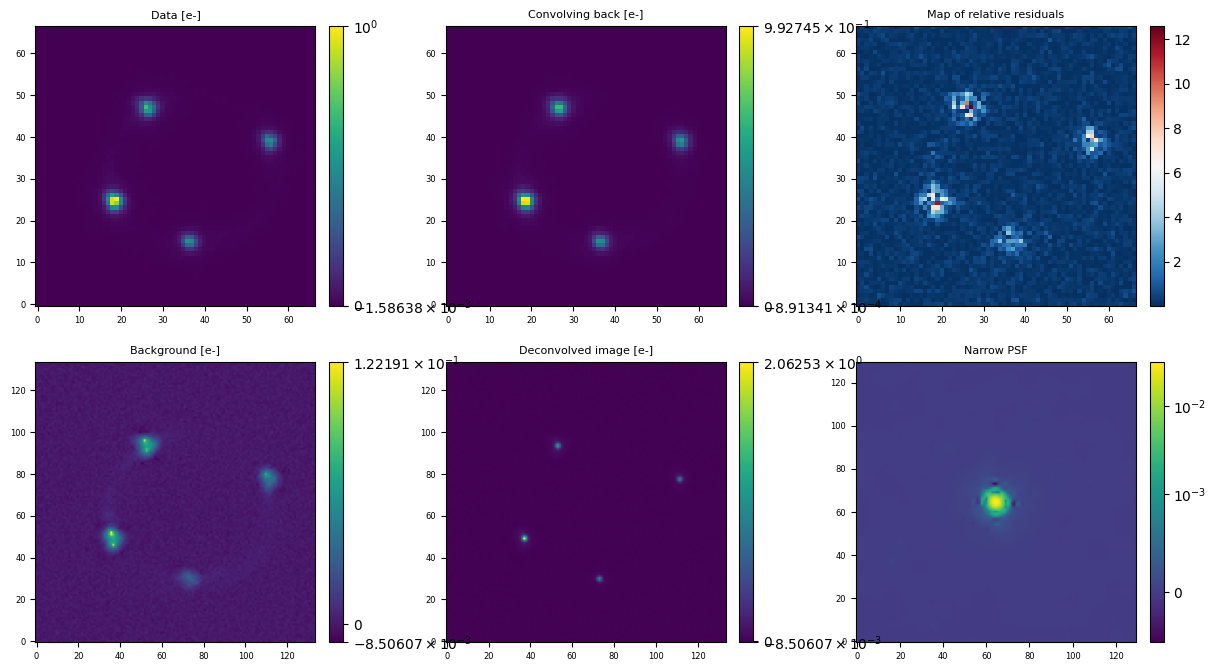

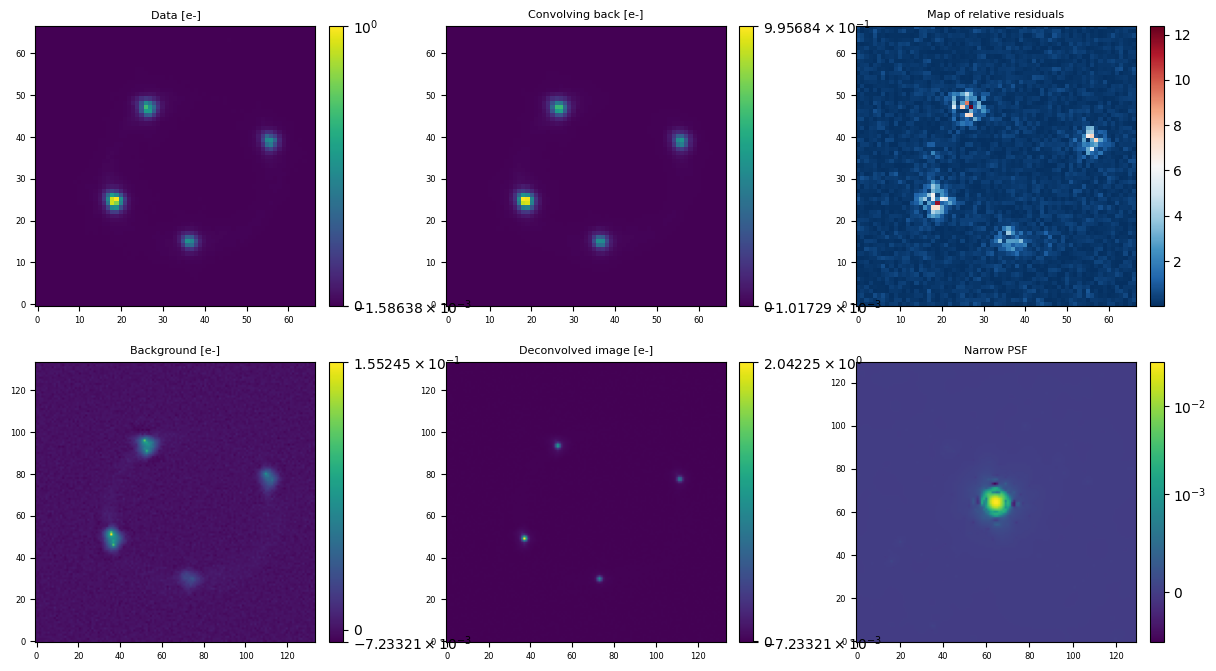

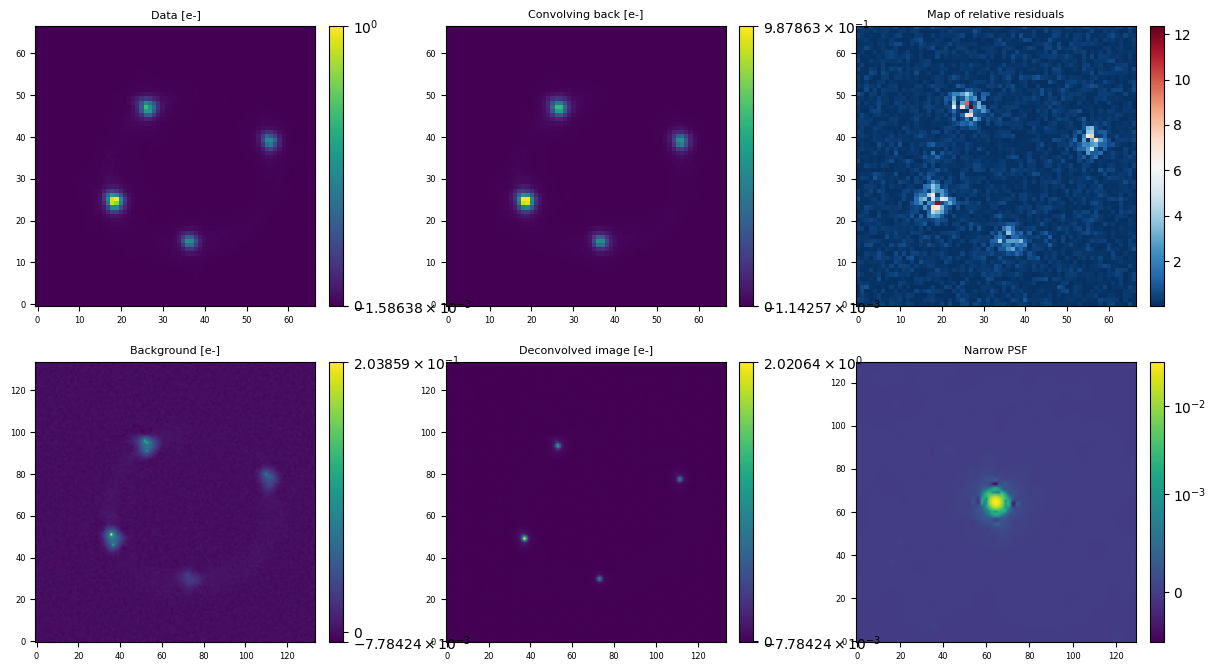

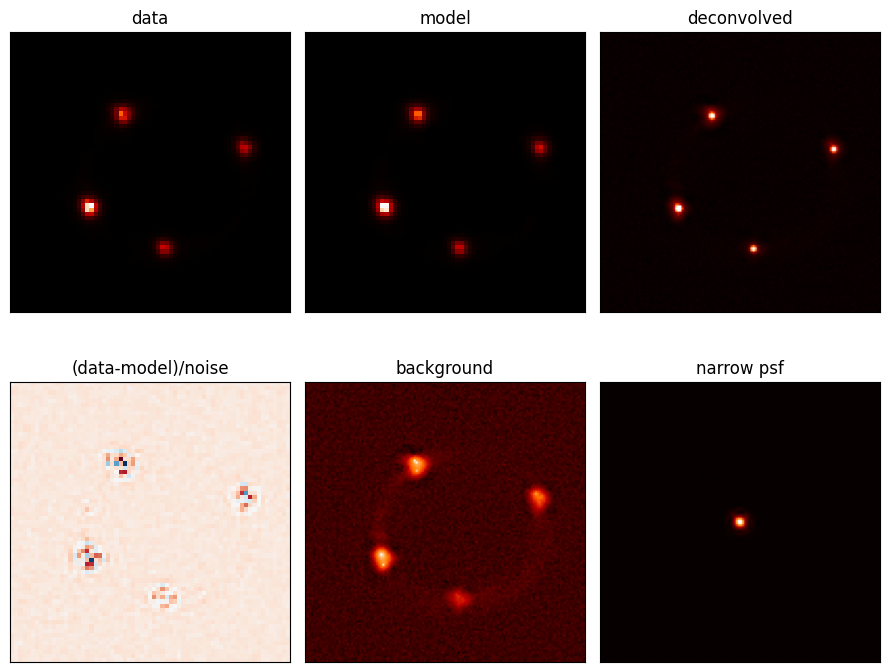

In [68]:
model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = (
    multi_steps_deconvolution(
        data,
        model,
        parameters,
       sigma2,
        narrow_psfs,
        subsampling_factor=subsampling_factor,
        lambda_scales=1., lambda_hf=500., lambda_positivity_bkg=100, lambda_positivity_ps=100,
        lambda_pts_source=1., prior_list=None, regularize_full_model=False,num_samples_noise=500,
        update_lambda_pts_source=False,
    )
)
kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
view_deconv_model(model, kwargs_final, data, sigma2)